# Лабораторная работа №5 (часть 2). Ансамбли моделей: стекинг, многослойный персептрон и МГУА

**Курс:** Технологии машинного обучения

**Цель работы:** изучение ансамблевых моделей машинного обучения.

**Задание:**
1. Выбрать набор данных (датасет) для решения задачи классификации или регрессии.
2. В случае необходимости провести удаление или заполнение пропусков и кодирование категориальных признаков.
3. С использованием метода `train_test_split` разделить выборку на обучающую и тестовую.
4. Обучить следующие модели: одну из моделей группы стекинга; многослойный персептрон (можно использовать TensorFlow или PyTorch); *(опционально)* два метода группы МГУА: один линейный (COMBI / MULTI) и один нелинейный (MIA / RIA).
5. Оценить качество моделей с помощью подходящих для задачи метрик и сравнить качество полученных моделей.

Ссылка на постановку задания: https://github.com/ugapanyuk/courses_current/wiki/LAB_TMO_ENSEMBLES_2

## 1. Выбор набора данных

Используется датасет **Medical Cost Personal Datasets** с сайта [kaggle.com](https://www.kaggle.com/datasets/mirichoi0218/insurance) (`mirichoi0218/insurance`), файл `data/insurance.csv` — медицинские страховые расходы 1338 клиентов.
Задача **регрессии**: предсказать `charges` (страховые расходы, доллары США) по признакам `age`, `sex`, `bmi`, `children`, `smoker`, `region`. Регрессия выбрана ещё и потому, что методы МГУА решают только задачи регрессии.
В датасете нет пропусков, но есть категориальные признаки (`sex`, `smoker`, `region`) и один дубликат строки.

In [1]:
import warnings, itertools
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import StackingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

In [2]:
data = pd.read_csv("data/insurance.csv")
print("Размер набора данных:", data.shape)
data.head()

Размер набора данных: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
miss = data.isna().sum().to_frame("Пропусков")
miss["Доля, %"] = (miss["Пропусков"] / len(data) * 100).round(2)
print("Типы признаков:"); print(data.dtypes.to_string()); print()
print("Полных дубликатов строк:", data.duplicated().sum())
data = data.drop_duplicates().reset_index(drop=True)
print("Размер после удаления дубликатов:", data.shape); print()
miss

Типы признаков:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64

Полных дубликатов строк: 1
Размер после удаления дубликатов: (1337, 7)



,Пропусков,"Доля, %"
age,0,0.0
sex,0,0.0
bmi,0,0.0
children,0,0.0
smoker,0,0.0
region,0,0.0
charges,0,0.0


## 2. Предобработка и разделение выборки

Дубликат строки удалён (см. выше). Пропусков нет, поэтому `SimpleImputer` оставлен лишь как защитный шаг; категориальные признаки `sex`, `smoker`, `region` кодируются One-Hot, числовые стандартизуются (это важно для персептрона и МГУА). Выборка делится `train_test_split` в пропорции 75/25.

In [4]:
X = data.drop(columns=["charges"])
y = data["charges"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

num_cols = X.select_dtypes("number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()
preprocess = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])
Xtr = preprocess.fit_transform(X_train)
Xte = preprocess.transform(X_test)
feature_names = [f.split("__")[1] for f in preprocess.get_feature_names_out()]
print("Обучающая:", Xtr.shape, " Тестовая:", Xte.shape)
print("Признаки:", feature_names)

Обучающая: (1002, 11)  Тестовая: (335, 11)
Признаки: ['age', 'bmi', 'children', 'sex_female', 'sex_male', 'smoker_no', 'smoker_yes', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']


## 3. Модель группы стекинга

`StackingRegressor`: базовые модели — случайный лес, градиентный бустинг и SVR (с RBF-ядром); метамодель — `RidgeCV`, обучается на out-of-fold предсказаниях базовых моделей (5-кратная кросс-валидация).

In [5]:
stacking = StackingRegressor(
    estimators=[("rf", RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)),
                ("gb", GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=RANDOM_STATE)),
                ("svr", SVR(C=10, gamma="scale"))],
    final_estimator=RidgeCV(), cv=5)
stacking.fit(Xtr, y_train)
print("Веса метамодели (rf, gb, svr):", stacking.final_estimator_.coef_.round(3),
      " свободный член: %.3f" % stacking.final_estimator_.intercept_)

Веса метамодели (rf, gb, svr): [ 0.114  0.885 -0.059]  свободный член: 535.511


## 4. Многослойный персептрон

Используется `MLPRegressor` из scikit-learn: два скрытых слоя (64 и 32 нейрона, ReLU), оптимизатор Adam, ранняя остановка по валидационной части обучающей выборки.

Число эпох: 459  Лучшее значение на валидации (R²): 0.8237


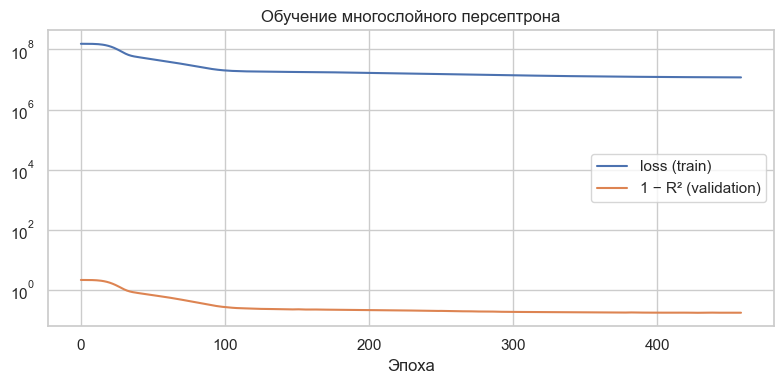

In [6]:
mlp = MLPRegressor(hidden_layer_sizes=(64, 32), activation="relu", solver="adam", alpha=1e-3,
                   learning_rate_init=0.005, max_iter=2000, early_stopping=True,
                   validation_fraction=0.15, n_iter_no_change=30, random_state=RANDOM_STATE)
mlp.fit(Xtr, y_train)
print("Число эпох:", mlp.n_iter_, " Лучшее значение на валидации (R²): %.4f" % mlp.best_validation_score_)
plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_, label="loss (train)")
plt.plot(1 - np.array(mlp.validation_scores_), label="1 − R² (validation)")
plt.yscale("log"); plt.xlabel("Эпоха"); plt.legend(); plt.title("Обучение многослойного персептрона")
plt.tight_layout(); plt.show()

## 5. Методы группы МГУА (метод группового учёта аргументов)

Библиотека `gmdh` (Python-обёртка над C++-ядром) не устанавливается на данной машине: для сборки требуется Boost ≥ 1.79 и принятая лицензия Xcode. Поэтому оба метода МГУА реализованы вручную на NumPy в соответствии с описанием алгоритмов:

- **COMBI** (линейный, комбинаторный): перебираются все непустые подмножества признаков, для каждого строится линейная регрессия по МНК на части выборки *A*; внешний критерий регулярности — среднеквадратичная ошибка на части *B*. Выбирается подмножество с минимальным критерием, затем модель пересчитывается на всей обучающей выборке.
- **MIA** (многорядный, нелинейный): на каждом ряду для всех пар входов строятся частные описания — полиномы 2-й степени  `y = a0 + a1·xi + a2·xj + a3·xi·xj + a4·xi² + a5·xj²`. Коэффициенты подбираются на *A*, отбор лучших `F` нейронов — по ошибке на *B*. Выходы отобранных нейронов становятся входами следующего ряда; наращивание рядов прекращается, когда ошибка на *B* перестаёт убывать, но не более `max_layers` рядов. Ограничение числа рядов (`max_layers`) — способ регуляризации: степень итогового полинома растёт как 2ᵏ, и при большом числе рядов модель неустойчива при экстраполяции. По 5-кратной кросс-валидации на обучающей выборке средний R² равен: 1 ряд — 0.719, 2 ряда — 0.807, 3 ряда — 0.808, 5 рядов — 0.818, а при 10 рядах модель расходится (R² ≈ −4918). Выбрано `max_layers = 5`.

In [7]:
class COMBI(BaseEstimator, RegressorMixin):
    """Линейный МГУА: полный перебор подмножеств признаков + внешний критерий регулярности."""
    def __init__(self, test_size=0.33, random_state=RANDOM_STATE):
        self.test_size, self.random_state = test_size, random_state

    def fit(self, X, y):
        y = np.asarray(y, float)
        A, B, yA, yB = train_test_split(X, y, test_size=self.test_size, random_state=self.random_state)
        best = (np.inf, None)
        for k in range(1, X.shape[1] + 1):
            for cols in itertools.combinations(range(X.shape[1]), k):
                cols = list(cols)
                m = LinearRegression().fit(A[:, cols], yA)
                err = mean_squared_error(yB, m.predict(B[:, cols]))
                if err < best[0]: best = (err, cols)
        self.criterion_, self.cols_ = best
        self.model_ = LinearRegression().fit(X[:, self.cols_], y)
        return self

    def predict(self, X):
        return self.model_.predict(X[:, self.cols_])


def _poly(xi, xj):
    return np.column_stack([np.ones_like(xi), xi, xj, xi * xj, xi ** 2, xj ** 2])


class MIA(BaseEstimator, RegressorMixin):
    """Нелинейный многорядный МГУА с частными описаниями — полиномами 2-й степени."""
    def __init__(self, n_best=8, max_layers=5, test_size=0.33, random_state=RANDOM_STATE):
        self.n_best, self.max_layers, self.test_size, self.random_state = n_best, max_layers, test_size, random_state

    def fit(self, X, y):
        y = np.asarray(y, float)
        idxA, idxB = train_test_split(np.arange(len(y)), test_size=self.test_size, random_state=self.random_state)
        Z = X.copy(); self.layers_ = []; self.history_ = []; best_err = np.inf
        for layer in range(self.max_layers):
            neurons = []
            for i, j in itertools.combinations(range(Z.shape[1]), 2):
                P = _poly(Z[:, i], Z[:, j])
                w = np.linalg.lstsq(P[idxA], y[idxA], rcond=None)[0]
                err = mean_squared_error(y[idxB], P[idxB] @ w)
                neurons.append((err, i, j, w))
            neurons.sort(key=lambda t: t[0]); neurons = neurons[: self.n_best]
            if neurons[0][0] >= best_err: break          # ошибка на B перестала убывать
            best_err = neurons[0][0]; self.history_.append(best_err)
            self.layers_.append([(i, j, w) for _, i, j, w in neurons])
            Z = np.column_stack([_poly(Z[:, i], Z[:, j]) @ w for _, i, j, w in neurons])
        self.criterion_ = best_err
        return self

    def predict(self, X):
        Z = X
        for layer in self.layers_:
            Z = np.column_stack([_poly(Z[:, i], Z[:, j]) @ w for i, j, w in layer])
        return Z[:, 0]      # выход лучшего нейрона последнего ряда

combi = COMBI().fit(Xtr, y_train)
mia = MIA().fit(Xtr, y_train)
print("COMBI: выбрано признаков %d из %d:" % (len(combi.cols_), Xtr.shape[1]), [feature_names[c] for c in combi.cols_])
print("COMBI: критерий регулярности (MSE на B) = %.3f" % combi.criterion_)
print("MIA: число рядов =", len(mia.layers_), "; MSE на B по рядам:", np.round(mia.history_, 3))

COMBI: выбрано признаков 6 из 11: ['age', 'bmi', 'children', 'smoker_no', 'region_northwest', 'region_southeast']
COMBI: критерий регулярности (MSE на B) = 39146832.387
MIA: число рядов = 5 ; MSE на B по рядам: [41071927.772 28035766.249 27749650.004 27568149.222 25996069.381]


## 6. Оценка качества моделей

Метрики: **MAE**, **RMSE** и **R²** на тестовой выборке, а также средний R² при 5-кратной кросс-валидации на обучающей выборке. В сравнение включена линейная регрессия как базовая линия.

In [8]:
models = {
    "Линейная регрессия (база)": LinearRegression().fit(Xtr, y_train),
    "Стекинг": stacking,
    "Персептрон (MLP)": mlp,
    "МГУА COMBI (линейный)": combi,
    "МГУА MIA (нелинейный)": mia,
}
kf = KFold(5, shuffle=True, random_state=RANDOM_STATE)
rows, preds = [], {}
for name, m in models.items():
    p = m.predict(Xte); preds[name] = p
    cv = cross_val_score(m, Xtr, y_train, cv=kf, scoring="r2").mean()
    rows.append({"Модель": name, "MAE": mean_absolute_error(y_test, p),
                 "RMSE": mean_squared_error(y_test, p) ** 0.5, "R2": r2_score(y_test, p), "R2 (CV, 5 фолдов)": cv})
res = pd.DataFrame(rows).set_index("Модель").round(4)
res.sort_values("R2", ascending=False)

,MAE,RMSE,R2,"R2 (CV, 5 фолдов)"
Модель,,,,
Стекинг,2581.0780,4462.5172,0.8848,0.8353
МГУА MIA (нелинейный),2680.6336,4585.9112,0.8784,0.8175
Персептрон (MLP),2927.8946,4649.8836,0.8750,0.8180
Линейная регрессия (база),4069.0395,5940.0272,0.7959,0.7231
МГУА COMBI (линейный),4081.9518,5961.7823,0.7944,0.7228


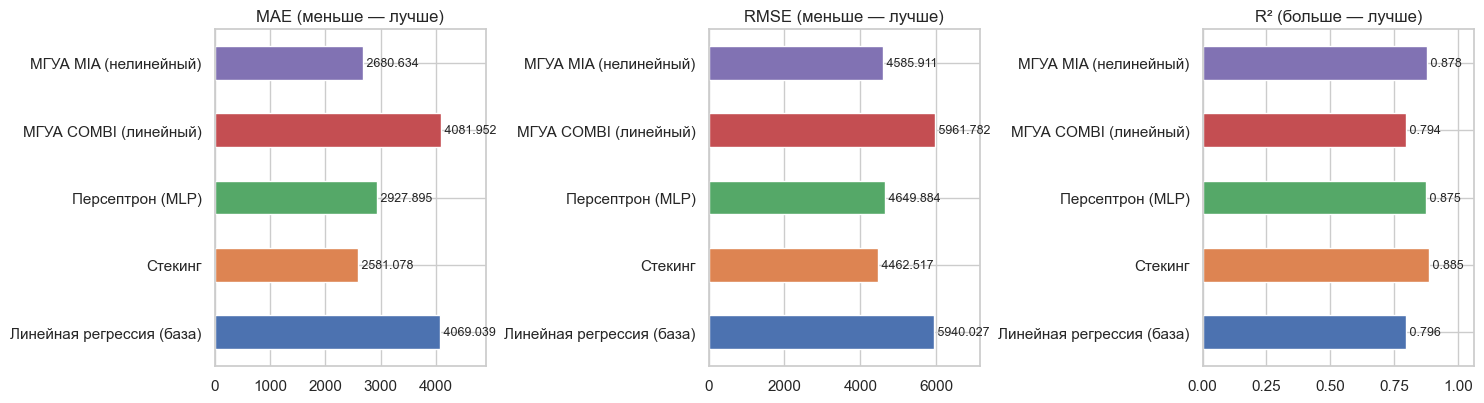

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, col, title in zip(axes, ["MAE", "RMSE", "R2"], ["MAE (меньше — лучше)", "RMSE (меньше — лучше)", "R² (больше — лучше)"]):
    res[col].plot.barh(ax=ax, color=sns.color_palette("deep", len(res)))
    ax.set_title(title); ax.set_ylabel("")
    for i, v in enumerate(res[col]): ax.text(v, i, " %.3f" % v, va="center", fontsize=9)
    ax.margins(x=0.2)
plt.tight_layout(); plt.show()

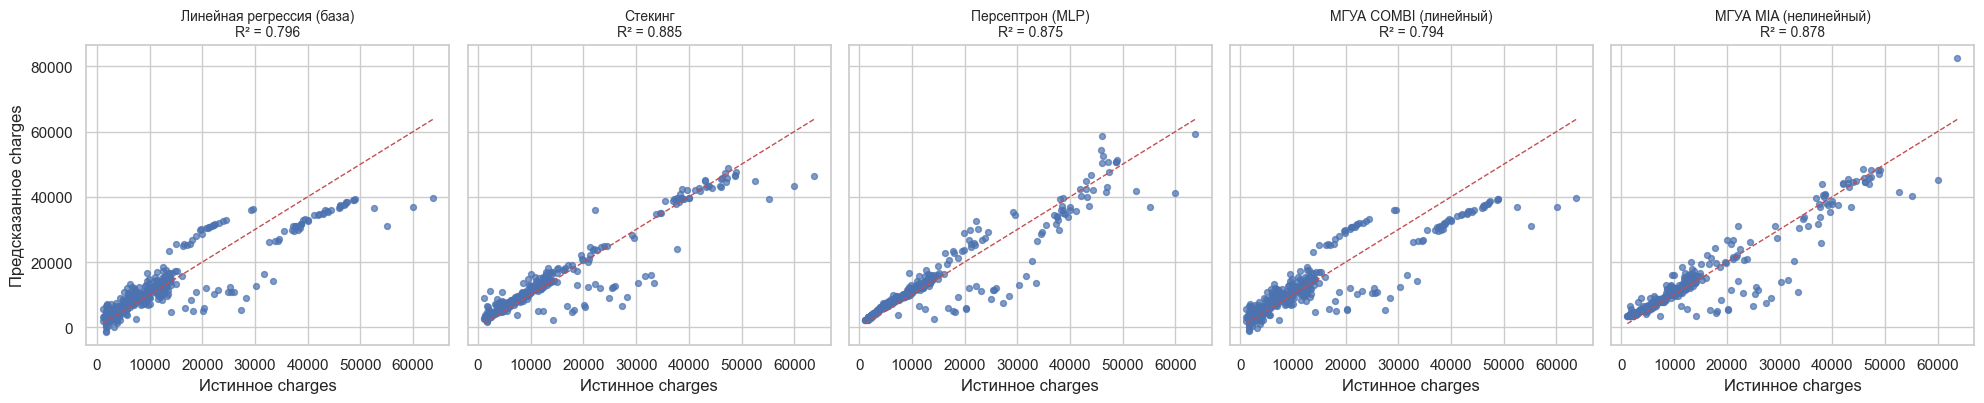

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4.2), sharex=True, sharey=True)
lim = [y.min() - 1, y.max() + 1]
for ax, name in zip(axes, models):
    ax.scatter(y_test, preds[name], s=18, alpha=.7); ax.plot(lim, lim, "r--", lw=1)
    ax.set_title("%s\nR² = %.3f" % (name, r2_score(y_test, preds[name])), fontsize=10); ax.set_xlabel("Истинное charges")
axes[0].set_ylabel("Предсказанное charges")
plt.tight_layout(); plt.show()

## 7. Выводы

- Использован датасет Medical Cost Personal Datasets с Kaggle (`mirichoi0218/insurance`), регрессия `charges`. Пропусков нет, удалён один дубликат (1337 строк); категориальные признаки закодированы One-Hot, числовые стандартизованы, выборка разделена `train_test_split` (1002 / 335 объектов).
- Обучены: стекинг (случайный лес + градиентный бустинг + SVR, метамодель RidgeCV), многослойный персептрон (64-32, ReLU, Adam, ранняя остановка) и два метода МГУА — линейный COMBI и нелинейный MIA (реализованы вручную, так как библиотека `gmdh` не собралась: нужен Boost и принятая лицензия Xcode).
- **Лучшая модель — стекинг**: R² = 0.885, MAE = 2581, RMSE = 4463 на тесте и лучший средний R² по кросс-валидации (0.835). Метамодель почти целиком опирается на градиентный бустинг (вес 0.885), случайному лесу дала 0.114, а SVR — небольшой отрицательный вес (−0.059): выигрыш стекинга над одиночным градиентным бустингом из части 1 (R² = 0.885) практически нулевой.
- **МГУА MIA** (R² = 0.878, MAE = 2681, CV 0.818) и **многослойный персептрон** (R² = 0.875, MAE = 2928, CV 0.818) показывают близкое качество и заметно лучше линейных моделей: нелинейные зависимости (влияние `smoker` в сочетании с `bmi`) линейная модель уловить не может. Пять рядов MIA сформировали полином высокой степени; при 10 рядах алгоритм расходится, поэтому число рядов ограничено пятью (подбор по кросс-валидации).
- **МГУА COMBI** (R² = 0.794, MAE = 4082) практически совпадает с линейной регрессией (R² = 0.796, MAE = 4069): из 11 признаков выбрано 6 (`age`, `bmi`, `children`, `smoker_no`, `region_northwest`, `region_southeast`), но линейная модель принципиально не описывает взаимодействие `smoker` и `bmi`, поэтому качество не выросло. Плюс метода — интерпретируемая модель с меньшим числом признаков при том же качестве.
- Итоговое ранжирование по R² на тесте: стекинг (0.885) > MIA (0.878) > MLP (0.875) > линейная регрессия (0.796) ≈ COMBI (0.794). Стекинг, MIA и MLP различаются менее чем на 0.01 по R² при тестовой выборке в 335 объектов, поэтому порядок между ними неустойчив; принципиальный разрыв — между нелинейными моделями и линейными (около 0.08 по R²).
- Для сравнения, в части 1 лучший одиночный ансамбль (градиентный бустинг) дал R² = 0.885, то есть стекинг его не улучшил, а лишь сравнялся с ним.